<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Parcial4_AstroPos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediccion De Las Fechas de Los Eclipses Del 2023**
<br>

### &nbsp; **Astronomía de Posición:** &nbsp;&nbsp;Parcial $4$ - Parte practica

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*





<br>

___

In [ ]:
# Librerias
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import files
from astropy.time import Time
from datetime import datetime
%matplotlib inline

ast = !pip install astroquery
from astroquery.jplhorizons import Horizons

In [ ]:
# algunos parametros
rad    = np.pi/180        # grados a radianes
h_2_g  = 15               # horas a grados
J2000  = 2451545.0        # JD 2000
e      = 23.44*rad        # oblicuidad [rads]

# **PUNTO 1) .**

###**(A) Encontrar la distancia angular entre el Sol y el nodo ascendente de la órbita lunar para cada día del 2023.**

<p align="justify"> Para encontrar la distancia angular entre el sol y el nodo ascendente lunar se requiere la longitud eclíptica de ambos.

<br>

**La longitud del nodo lunar ascendente $\Omega$** se obtiene mediante la ecuación:

$$ \Omega = \Omega_{0}[^{\circ}] -\omega_{\Omega} [^{\circ}/\textrm{siglo}] \cdot  T [\textrm{siglo}] $$

$$ \Omega = 125.04^{\circ} -1934.13 [^{\circ}/\textrm{siglo}] \cdot  T [\textrm{siglo}] $$

$$ \Omega = 125.04^{\circ} -0.05295 [^{\circ}/\textrm{dias}] \cdot  T [\textrm{dias}] $$

$$ \Omega = 125.04^{\circ} -2.2064*10^{-3} [^{\circ}/\textrm{h}] \cdot  T [\textrm{h}] $$

> <p align="justify"> Donde $ \Omega_{0}$ es el ángulo del nodo lunar medido en la época de partida J2000, $\omega_{\Omega}$ es la velocidad angular del nodo lunar, y la variable $T = \frac{(JD-J2000)}{36525} [\textrm{siglo}] = (JD-J2000)[\textrm{dias}]=24*(JD-J2000)[\textrm{h}]$.  El propósito de pasar la velocidad angular del nodo de [°/siglo] a [°/h] es aumentar la precisión en las cifras de la longitud del nodo.



<br>

**La longitud del sol $\lambda_{\odot }$** se puede obtener mediante las siguientes dos formas, pero en principio el  resultado debería ser el mismo.

* La primera es mediante la fórmula de longitud solar en función del día del año ($d$):
$$ \lambda_{\odot } = \omega_{\odot}(d-81) $$

* la segunda es tomar las coordenadas ecuatoriales del Sol durante el 2023 de Astroquery y mediante transformación a Eclípticas se obtiene la longitud del sol.  </p>

<br>


**Forma 1:** DATOS DEL SOL DE ASTROQUERY


In [ ]:
# intervalo de tiempo deseado para los datos
start = datetime(2023,1,1)
end   = datetime(2023,12,31)
step_size ='1d'

interval = {'start':start.strftime("%Y-%m-%d %H:%M"),
            'stop':end.strftime("%Y-%m-%d %H:%M"),
            'step':step_size}

sol = Horizons(id='sun',location='500@3',epochs=interval) # objeto a estudar
sol_eph = sol.ephemerides()                               # efemerides:RA,DEC...

In [ ]:
# Arreglos de los datos del sol
ra_sol   = np.array(sol_eph['RA_app'])       # [°]
dec_sol  = np.array(sol_eph['DEC_app'])      # [°]
date_sol = np.array(sol_eph['datetime_str']) # [yyyy-mm-dd hh:mm]
JD_sol   = np.array(sol_eph['datetime_jd'])  # [dias julianos]
ut_date = pd.to_datetime(date_sol)           # fecha a datetime

In [ ]:
ut_date

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[ns]', length=365, freq=None)

In [ ]:
# Longitud del nodo lunar, usando los datos de dia juliano de astroquery

T = (JD_sol-J2000)*24                     # variable  T [h]
Ω = 125.04 - (1934.13/(100*365.25*24))*T  # longitud del nodo lunar asc. [°]

for i in range(len(Ω)):
    Ω[i] = (Ω[i] - int(Ω[i] /360)*360)    # angulos a primer circulo [rad]
    if Ω[i] < 0: Ω[i] = Ω[i] + 360        # caso angulos negativos [rad]

# haciendo la comparacion de Ω con las variables temporales en siglos y dias muchos valores coinciden pero no todos, luego si es relativamente mas preceiso usar horas

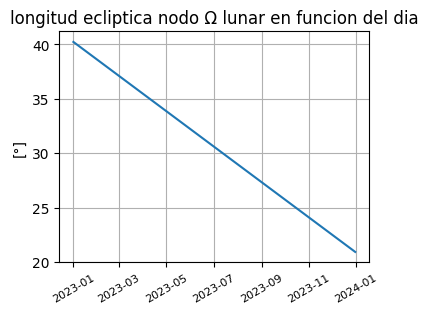

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(ut_date, Ω)
plt.title('longitud ecliptica nodo Ω lunar en funcion del dia')
plt.ylabel('[°]')
plt.grid()
plt.tick_params(axis='x', labelrotation = 30, labelsize=8)

In [ ]:
# para la longitud del sol se requiere una transformacion de Ecuatoriales a Eclipticas

def ecu_2_eclip(ra,dec):  # de Ecuatoriales a eclipticas [rad,rad]
  β = np.arcsin( np.sin(dec)*np.cos(e) - np.cos(dec)*np.sin(e)*np.sin(ra)  )
  p = np.sin(dec)*np.sin(e) + np.cos(dec)*np.cos(e)*np.sin(ra) # numerador
  q = np.cos(ra)*np.cos(dec)                                   # denominador
  λ = np.arctan( p/q )

  if p*q<0 and q<0:   λ = λ + np.pi    # condiciones de cuadrante
  elif p*q<0 and q>0: λ = λ + 2*np.pi
  elif p+q <0:        λ = λ + np.pi
  return β,λ                           # [rad,rad]

λ_sol = np.zeros(len(ra_sol))          # Arreglos vacios para cada coordenada
β_sol = np.zeros(len(ra_sol))

for i in range(len(ra_sol)):           # Transformacion de cada valor
  β_sol[i], λ_sol[i] = ecu_2_eclip(  ra_sol[i]*rad, dec_sol[i]*rad ) #

β_sol = β_sol/rad ; λ_sol = λ_sol/rad  # Coords eEclipticas [°]


# longitud del sol forma 2: ecuacion ------------------------------------------

dias = np.arange(0,365,1)              # arreglo de dias del 2023
long_sol = (360/365.25)*(dias-81)      # ecuacion longitud eclip del sol

for i in range(len(dias)):
  if long_sol[i]<0: long_sol[i] = long_sol[i]+360  # angulos no negativos

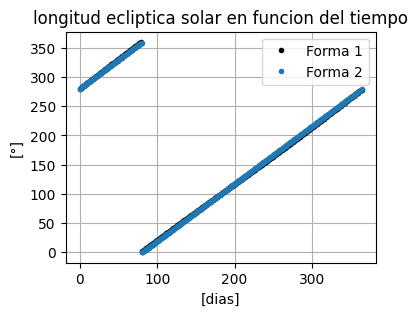

In [ ]:
# comparacion longitudes solares por los dos metodos
plt.figure(figsize=(4,3))
plt.plot(dias, λ_sol,'k.',label='Forma 1')
plt.plot(dias, long_sol,'.',label='Forma 2')
plt.title('longitud ecliptica solar en funcion del tiempo')
plt.xlabel('[dias]')
plt.ylabel('[°]')
plt.grid()
plt.legend()

<p align="justify"> A través de ambos métodos se obtiene longitudes eclípticas del sol prácticamente idénticas, por lo que de aquí en adelante se tomó la del método 1: con los datos de Astroquery

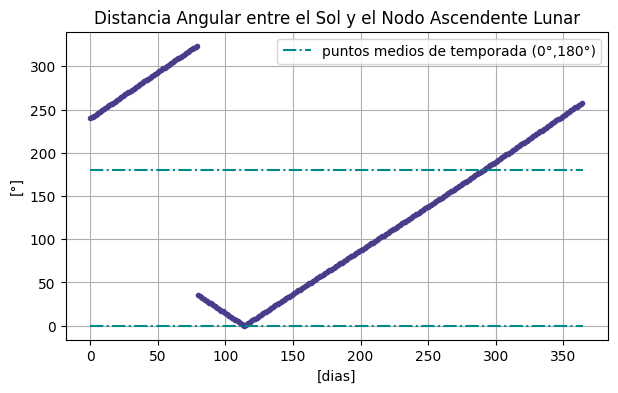

In [ ]:
# Distancia angular entre el Sol y el nodo ascendente de la  ́orbita lunar

d = np.abs( λ_sol - Ω )

plt.figure(figsize=(7,4))
plt.plot(dias, d,'.', c='#483D8B')
plt.title('Distancia Angular entre el Sol y el Nodo Ascendente Lunar')
plt.hlines(0, 0,365, linestyle='-.', colors='#008B8B', label='puntos medios de temporada (0°,180°)')
plt.hlines(180, 0,365, linestyle='-.',colors='#008B8B')
plt.ylabel('[°]')
plt.xlabel('[dias]')
plt.grid()
plt.legend()
# plt.tick_params(axis='x', labelrotation = 30, labelsize=8)

<p align="justify"> En la intersección de la curva de distancia angular Sol-Nodo lunar con las líneas horizontales fijadas en el valor 0° y 180° se produce el punto medio de las dos temporadas de eclipses, y representa la intersección entre la órbita de la luna y la eclíptica </p>

<br><br>

###**(B) Estimación del inicio y final de las temporadas de eclipses del año 2023**


<p align="justify"> La distancia angular que cubre una temporada de eclipses es aproximadamente $30$° centrada en el punto medio, por lo que el sol deberá estar a aproximadamente $15$° del Nodo o punto medio de temporada para que comience o finalice la temporada. Analogamente en lugar de tomar el angulo de media temporada de eclipses, se puede tomar el tiempo medio, sabiendo que el tiempo total esta entre 33 dias  y 37 dias. De este modo se llegaran a las fechas de inicio y fin de las temporadas por la parte angular y temporal a continuacion:
 </p>


In [ ]:
# Primero encontrando los puntos medios de las temporadas
d_0 = d[ (d < 0.1)  ]                       # boolean mask para 0 aproximado
d_180 = d[ (d < 180.5) & (d > 179.5) ]      # boolean mask para 180 aproximado

# indices de los puntos medios de la temporada
ind_0 = np.where( d == d_0 )      # indic del 0
ind_180 = np.where( d == d_180 )  # indic del 0

# tiempo de ocurrencia de los puntos medios de temporada
print('Fecha del punto medio de la 1r temporada: ', ut_date[ind_0][0])
print('Fecha del punto medio de la 2d temporada: ', ut_date[ind_180][0])

Fecha del punto medio de la 1r temporada:  2023-04-25 00:00:00
Fecha del punto medio de la 2d temporada:  2023-10-19 00:00:00


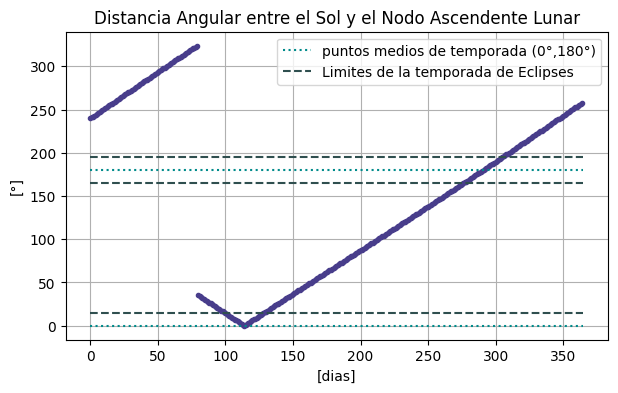

In [ ]:
# angularmente la mitad de la temporada es aproximadamente 15° antes y despues del punto medio
d1_f = d_0 + 15   # distancia alngular de inicio y fin de temporada 1 (estan sobre la misma linea horizontal de angulo 0°)
d2_i = d_180 - 15 # distancia alngular de inicio y fin de temporada 2
d2_f = d_180 + 15

plt.figure(figsize=(7,4))
plt.plot(dias, d,'.', c='#483D8B')
plt.title('Distancia Angular entre el Sol y el Nodo Ascendente Lunar')
plt.hlines(0, 0,365, linestyle=':', colors='#008B8B', label='puntos medios de temporada (0°,180°)')
plt.hlines(180, 0,365, linestyle=':',colors='#008B8B')
plt.hlines(d1_f, 0,365, linestyle='--',colors='#2F4F4F', label='Limites de la temporada de Eclipses')
plt.hlines(d2_i, 0,365, linestyle='--',colors='#2F4F4F')
plt.hlines(d2_f, 0,365, linestyle='--',colors='#2F4F4F')
plt.ylabel('[°]')
plt.xlabel('[dias]')
plt.grid()
plt.legend()

In [ ]:
# Fechas de las temporadas: Aproximacion por angulos

d_1 = d[ (d < d1_f + 0.5) & (d > d1_f - 0.5)  ]  # distancia angular asociada a los limites de temporada 1
d_2i = d[ (d < d2_i+ 0.5 ) & (d > d2_i- 0.5) ]   # distancia angular asociada a los limites de temporada 2
d_2f = d[ (d < d2_f+ 0.5 ) & (d > d2_f- 0.5) ]

i_1 = [] # indices de inicio y fin 1r temporada
i_2 = [] # indices de inicio 2d temporada
f_2 = [] # indices de fin 2d temporada

for i in range(len(d_1)):  # el for solo era necesario para la primer temporada pues el limite se repite en el mismo valor de diferencia angular
  i_1.append(np.where( d == d_1[i] )[0][0])

for i in range(len(d_2i)):
  i_2.append(np.where( d == d_2i[i] )[0][0])

for i in range(len(d_2f)):
  f_2.append(np.where( d == d_2f[i] )[0][0])

# indices de los limites de ambas temporadas
indx1_i, indx1_f = i_1
indx2_i, indx2_f = i_2[0], f_2[0]
print('Con la aproximacion por angulos:\n')
print('La 1r temporada de eclipses inicia el ',ut_date[indx1_i], ' y finaliza el ', ut_date[indx1_f] )
print('La 2d temporada de eclipses inicia el ',ut_date[indx2_i], ' y finaliza el ', ut_date[indx2_f] )

Con la aproximacion por angulos:

La 1r temporada de eclipses inicia el  2023-04-10 00:00:00  y finaliza el  2023-05-10 00:00:00
La 2d temporada de eclipses inicia el  2023-10-05 00:00:00  y finaliza el  2023-11-02 00:00:00


In [ ]:
# Fechas de las temporadas: Aproximacion por tiempos

Δt = pd.Timedelta('16.5 days')  # tiempo de media temporada (el total esta entre 33-37 dias)

temp1_i = ut_date[ind_0] - Δt   # tiempos inicio y fin temporada 1
temp1_f = ut_date[ind_0] + Δt

temp2_i = ut_date[ind_180] - Δt # tiempos inicio y fin temporada 2
temp2_f = ut_date[ind_180] + Δt

print('Con la aproximacion por tiempos:\n')
print('La 1r temporada de eclipses inicia el ',temp1_i[0], ' y finaliza el ', temp1_f[0] )
print('La 2d temporada de eclipses inicia el ',temp2_i[0], ' y finaliza el ', temp2_f[0] )

Con la aproximacion por tiempos:

La 1r temporada de eclipses inicia el  2023-04-08 12:00:00  y finaliza el  2023-05-11 12:00:00
La 2d temporada de eclipses inicia el  2023-10-02 12:00:00  y finaliza el  2023-11-04 12:00:00


**Discusion**
<p align="justify"> Se observa que los intervalos por ambas aproximaciones son muy parecidos, excepto por una desviación en un par de días, lo cual se puede explicar debido a que en caso de la aproximación por tiempos se tomó solo un intervalo (de Δt=33 días con mitad 16.5dias) de los posibles, sin embargo las temporadas están en el rango entre (33-37) días, por lo que por ese lado puede estar algo sesgado el procedimiento de aproximación por tiempos. </p>

<br><br>

###**(C) Distancia angular Sol-Luna durante las temporadas de eclipses. Estimación de sus fases y con esto los tipos de eclipses que puedan darse**



Para los **eclipses de sol** la luna debe estar en **fase nueva**, con diferencia de 0° en longitud eclíptica, mientras que para **eclipses de luna**, esta debe estar en **fase llena**, con diferencia de 180° en longitud.



<p align="center">
<img src=https://i.postimg.cc/J0vYZCX0/fases-luna.png width="400">
<br>
<font size=2>Fig1. Fases de la luna https://www.unprofesor.com/ciencias-naturales.</font></p>


Ya se tomaron los datos del sol en los puntos anteriores, ahora los de la luna:


In [ ]:
luna = Horizons(id='301',location='500@3',epochs=interval) # objeto a estudar
luna_eph = luna.ephemerides()                              # efemerides:RA,DEC

In [ ]:
# Arreglos de los datos de la luna
ra_lun   = np.array(luna_eph['RA_app'])       # [°]
dec_lun  = np.array(luna_eph['DEC_app'])      # [°]
date_lun = np.array(luna_eph['datetime_str']) # [yyyy-mm-dd hh:mm]
JD_lun   = np.array(luna_eph['datetime_jd'])  # [dias julianos]
ut_date_lun = pd.to_datetime(date_lun)           # fecha a datetime

In [ ]:
# Usando la funcion de transformacion de ecuatoriales a eclipticas se obtiene la longitud de la luna

λ_lun = np.zeros(len(ra_lun))          # Arreglos vacios para cada coordenada
β_lun = np.zeros(len(ra_lun))

for i in range(len(ra_lun)):           # Transformacion de cada valor
  β_lun[i], λ_lun[i] = ecu_2_eclip(  ra_lun[i]*rad, dec_lun[i]*rad )

β_lun = β_lun/rad ; λ_lun = λ_lun/rad  # Coords eEclipticas [°]

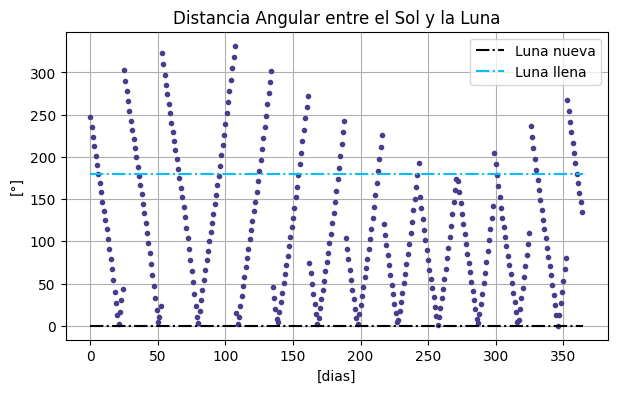

In [ ]:
# Distancia angular entre el Sol y la luna

d_sol_lun = np.abs( λ_sol - λ_lun )

plt.figure(figsize=(7,4))
plt.plot(dias, d_sol_lun,'.', c='#483D8B')
plt.title('Distancia Angular entre el Sol y la Luna')
plt.hlines(0, 0,365, linestyle='-.', colors='k', label='Luna nueva')
plt.hlines(180, 0,365, linestyle='-.',colors='#00BFFF', label='Luna llena')
plt.ylabel('[°]')
plt.xlabel('[dias]')
plt.grid()
plt.legend()

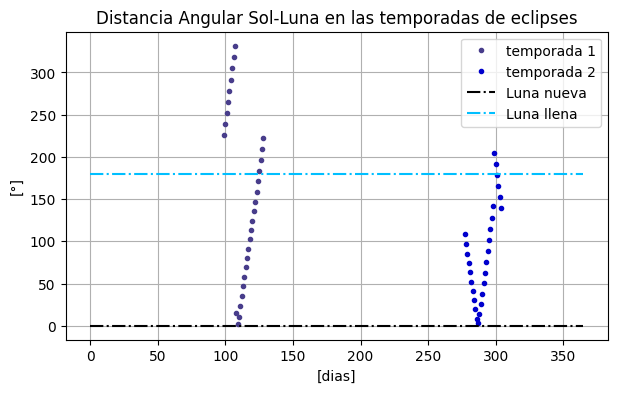

In [ ]:
d_sol_lun = np.abs( λ_sol - λ_lun )

plt.figure(figsize=(7,4))
plt.plot(dias[indx1_i:indx1_f], d_sol_lun[indx1_i:indx1_f],'.', c='#483D8B', label='temporada 1')
plt.plot(dias[indx2_i:indx2_f], d_sol_lun[indx2_i:indx2_f],'.', c='#0000CD', label='temporada 2')

plt.title('Distancia Angular Sol-Luna en las temporadas de eclipses')


plt.hlines(0, 0,365, linestyle='-.', colors='k', label='Luna nueva')
plt.hlines(180, 0,365, linestyle='-.',colors='#00BFFF', label='Luna llena')
plt.ylabel('[°]')
plt.xlabel('[dias]')
plt.grid()
plt.legend()


<p align="justify"> Se evidencian en ambas temporadas las dos ocasiones donde la distancia angular es la adecuada (0°,180°) para que la luna esté en fase Nueva o llena respectivamente, a primera vista se observa que ocurre primero la fase nueva y luego la llena, por tanto primero ocurrirá eclipse de sol y posteriormente el de luna

In [ ]:
# extraccion de la fecha de las fases

# diferencia angular sol-luna en las temporadas
d_temp1 = d_sol_lun[indx1_i: indx1_f]
d_temp2 = d_sol_lun[indx2_i: indx2_f]

# fases (llena o nueva) de la luna en cada temporada
fase1_t1 = d_temp1[ d_temp1 < 2.5  ]  # nueva
fase2_t1 = d_temp1[ (d_temp1 < 184 ) & (d_temp1 > 176) ] # llena

fase1_t2 = d_temp2[ d_temp2 < 3  ]    # nueva
fase2_t2 = d_temp2[ (d_temp2 < 184 ) & (d_temp2 > 176) ] #llena

# indices de los eclipses a partir del inicio de sus respectivas temporadas
i_ec1 = np.where( d_temp1  == fase1_t1 )[0][0]
i_ec2 = np.where( d_temp1  == fase2_t1 )[0][0]

i_ec3 = np.where( d_temp2  == fase1_t2 )[0][0]
i_ec4 = np.where( d_temp2  == fase2_t2 )[0][0]

# fechas de los eclipses
ecli_1 = ut_date[indx1_i:indx1_f][i_ec1 ]
ecli_2 = ut_date[indx1_i:indx1_f][i_ec2 ]
ecli_3 = ut_date[indx2_i:indx2_f][i_ec3 ]
ecli_4 = ut_date[indx2_i:indx2_f][i_ec4 ]

print('En la temporada 1')
print('Eclipse de sol (luna nueva): ', ecli_1)
print('Eclipse de luna (luna llena): ',  ecli_2)

print('\nEn la temporada 2')
print('Eclipse de sol (luna nueva): ', ecli_3)
print('Eclipse de luna (luna llena): ',  ecli_4)

En la temporada 1
Eclipse de sol (luna nueva)  2023-04-20 00:00:00
Eclipse de luna (luna llena)  2023-05-06 00:00:00

En la temporada 2
Eclipse de sol (luna nueva)  2023-10-15 00:00:00
Eclipse de luna (luna llena)  2023-10-29 00:00:00


<br>

###**(D) Comparación con los valores de la literatura**

Las fechas teóricas por parte del sitio web time and date para los eclipses del 2023 son:

Temporada 1:
> **$20$ Abril** : eclipse Solar (total) <br>
> **$5-6$ Mayo** : eclipse Lunar (penumbral) <br>

Temporada 2:
> **$14$ Octubre** : eclipse Solar (anular) <br>
> **$28-29$ Octubre** : eclipse Solar (parcial) <br>

<p align="justify"> Los valores encontrados son una muy buena aproximación a estos valores teóricos, coincidiendo con la mayoría y a lo sumo variando únicamente por un día. Las posibles mejoras en el método se pueden dar tomando un paso más pequeño a la hora de obtener los datos de la luna y el sol de Astorquery, en lugar de tomar 1 valor por día se podría aumentar el número lo que "suavizaría" la curva de distancia angular entre los dos cuerpos, de modo que a la hora de obtener los valores cercanos a las rectas constantes de interés en (0° y 180° tanto para las fases como para los puntos medios de temporada) tendrían una menor desviación que la encontrada anteriormente. Además, tomando pasos más pequeños se podrían tener en cuenta las horas con lo cual las fechas de los eclipses tendrían aun mayor precisión. Finalmente, también sería interesante implementar en el Código el cálculo, sea cual sea, para dar con el tipo particular del eclipse (sea total, penumbral, anular, o parcial) junto con un cálculo de las posibles ubicaciones desde las cuales se pueda ver el eclipse.




**Bibliografía:**

* Eclipses 2023, recuperado de: https://www.timeanddate.com/eclipse/2023

